# Dataset EDA and File Renaming

This notebook scans `data/train` and `data/test`, shows a light EDA summary, then prepares a rename plan for every image inside each class folder.

Rename format:

```text
<ClassName>_<3-digit-index>.<original-extension>
Cam_001.jpg
Cam_002.jpg
```

Default mode is `DRY_RUN = True`, so the notebook only previews the rename plan. Set `DRY_RUN = False` in the config cell when you want to apply the rename.


## 1. Imports and Configuration


In [12]:
from __future__ import annotations

from pathlib import Path
import hashlib
import re
import uuid

import pandas as pd
import matplotlib.pyplot as plt


SPLITS = ("train", "test")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

# Keep this True first to preview the rename plan.
# Change to False only when you are ready to rename files on disk.
DRY_RUN = False

# If True, .JPG becomes .jpg, .PNG becomes .png, etc.
NORMALIZE_EXTENSION_CASE = True

# The requested format is 3 digits. If a folder has more than 999 images,
# Python formatting automatically grows to 4+ digits instead of truncating.
INDEX_WIDTH = 3

# Train/test split rebuild settings.
# TEST_RATIO = 0.10 means the test split will contain 10% of all images per class
# after combining the current train and test folders.
TEST_RATIO = 0.10
SPLIT_SEED = 42
SPLIT_DRY_RUN = False


## 2. Path and File Helpers


In [13]:
def resolve_data_dir() -> Path:
    here = Path.cwd().resolve()
    for parent in [here, *here.parents]:
        candidate = parent / "data"
        if all((candidate / split).is_dir() for split in SPLITS):
            return candidate
    raise FileNotFoundError("Could not find data/train and data/test from the current notebook location.")


def natural_key(path: Path):
    parts = re.split(r"(\d+)", path.name.lower())
    return [int(part) if part.isdigit() else part for part in parts]


def list_class_dirs(split_dir: Path) -> list[Path]:
    return sorted([p for p in split_dir.iterdir() if p.is_dir()], key=lambda p: p.name.lower())


def list_image_files(class_dir: Path) -> list[Path]:
    files = [p for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]
    return sorted(files, key=natural_key)


DATA_DIR = resolve_data_dir()
PROJECT_DIR = DATA_DIR.parent
RENAME_LOG_DIR = PROJECT_DIR / "notebook_demo" / "rename_logs"
RENAME_LOG_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("DRY_RUN:", DRY_RUN)


DATA_DIR: E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\data
DRY_RUN: False


## 3. Light EDA: File Counts by Split and Class


In [14]:
rows = []
for split in SPLITS:
    split_dir = DATA_DIR / split
    for class_dir in list_class_dirs(split_dir):
        image_files = list_image_files(class_dir)
        all_files = [p for p in class_dir.iterdir() if p.is_file()]
        rows.append(
            {
                "split": split,
                "class": class_dir.name,
                "image_files": len(image_files),
                "non_image_files": len(all_files) - len(image_files),
                "folder": str(class_dir.relative_to(PROJECT_DIR)),
            }
        )

counts_df = pd.DataFrame(rows)
display(counts_df)

pivot_counts = counts_df.pivot_table(
    index="class",
    columns="split",
    values="image_files",
    fill_value=0,
    aggfunc="sum",
).astype(int)

display(pivot_counts)
print("Total image files:", int(counts_df["image_files"].sum()))


,split,class,image_files,non_image_files,folder
0,train,Cam,613,0,data\train\Cam
1,train,Chidan,568,0,data\train\Chidan
2,train,Hieulenh,588,0,data\train\Hieulenh
3,train,Nguyhiem,593,0,data\train\Nguyhiem
4,train,Phu,372,0,data\train\Phu
5,test,Cam,68,0,data\test\Cam
6,test,Chidan,62,0,data\test\Chidan
7,test,Hieulenh,64,0,data\test\Hieulenh
8,test,Nguyhiem,64,0,data\test\Nguyhiem
9,test,Phu,41,0,data\test\Phu


split,test,train
class,,
Cam,68,613
Chidan,62,568
Hieulenh,64,588
Nguyhiem,64,593
Phu,41,372


Total image files: 3033


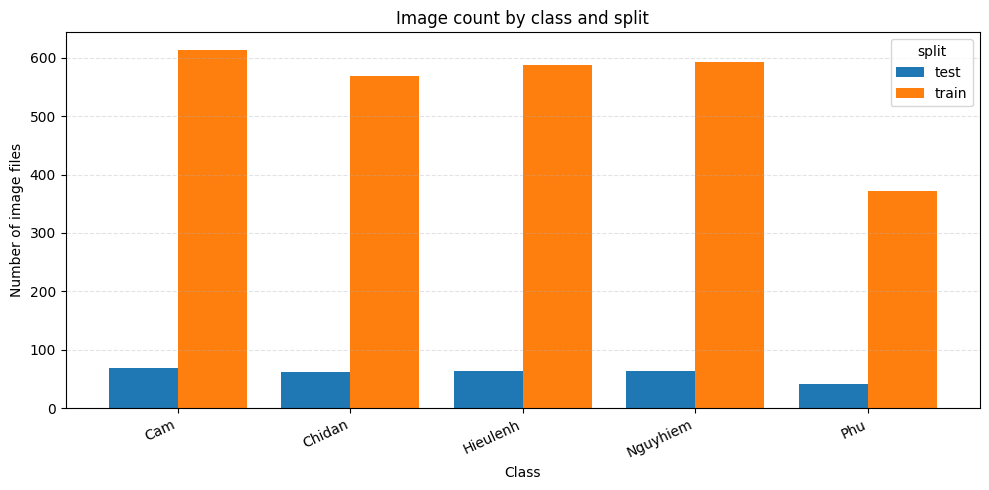

In [15]:
ax = pivot_counts.plot(kind="bar", figsize=(10, 5), width=0.8)
ax.set_title("Image count by class and split")
ax.set_xlabel("Class")
ax.set_ylabel("Number of image files")
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 4. Optional: Rebuild Train/Test Split

This section can rebuild `data/train` and `data/test` from all images currently present in both folders.

For each class, it combines current train + test files, shuffles deterministically, then sends `TEST_RATIO = 0.10` of that class to `test` and the rest to `train`.

Default mode is `SPLIT_DRY_RUN = True`, so it only previews what would move. Set `SPLIT_DRY_RUN = False` in the config cell when you want to apply the split.


In [16]:
def collect_all_images_by_class(data_dir: Path) -> dict[str, list[Path]]:
    class_names = sorted(
        {
            class_dir.name
            for split in SPLITS
            for class_dir in list_class_dirs(data_dir / split)
        }
    )

    by_class: dict[str, list[Path]] = {}
    for class_name in class_names:
        files: list[Path] = []
        for split in SPLITS:
            class_dir = data_dir / split / class_name
            if class_dir.exists():
                files.extend(list_image_files(class_dir))
        by_class[class_name] = sorted(files, key=lambda p: (p.suffix.lower(), natural_key(p)))
    return by_class


def build_split_plan(data_dir: Path, test_ratio: float, seed: int) -> pd.DataFrame:
    if not 0 < test_ratio < 1:
        raise ValueError("test_ratio must be between 0 and 1.")

    rows = []
    rng = __import__("random").Random(seed)
    images_by_class = collect_all_images_by_class(data_dir)

    for class_name, files in images_by_class.items():
        shuffled = list(files)
        rng.shuffle(shuffled)

        if len(shuffled) <= 1:
            test_count = 0
        else:
            test_count = max(1, round(len(shuffled) * test_ratio))
            test_count = min(test_count, len(shuffled) - 1)

        test_set = set(shuffled[:test_count])
        for old_path in files:
            target_split = "test" if old_path in test_set else "train"
            old_split = old_path.parents[1].name
            target_dir = data_dir / target_split / class_name
            needs_move = old_split != target_split

            if needs_move:
                rel_key = str(old_path.relative_to(data_dir)).replace("\\", "/")
                short_hash = hashlib.md5(rel_key.encode("utf-8")).hexdigest()[:10]
                temp_name = f"__split_pending__{short_hash}{old_path.suffix.lower()}"
                new_path = target_dir / temp_name
            else:
                new_path = old_path

            rows.append(
                {
                    "class": class_name,
                    "old_split": old_split,
                    "target_split": target_split,
                    "old_name": old_path.name,
                    "target_name": new_path.name,
                    "old_path": str(old_path),
                    "new_path": str(new_path),
                    "needs_move": needs_move,
                }
            )

    return pd.DataFrame(rows)


split_plan_df = build_split_plan(DATA_DIR, TEST_RATIO, SPLIT_SEED)
split_summary_df = split_plan_df.groupby(["class", "target_split"], as_index=False).agg(files=("old_name", "count"))
split_summary_pivot = split_summary_df.pivot_table(
    index="class",
    columns="target_split",
    values="files",
    fill_value=0,
    aggfunc="sum",
).astype(int)

move_preview_df = split_plan_df[split_plan_df["needs_move"]][
    ["class", "old_split", "target_split", "old_name"]
]

display(split_summary_pivot)
print("Total files in split plan:", len(split_plan_df))
print("Files that would move:", len(move_preview_df))
display(move_preview_df.head(30))
print("Moved files receive temporary names first; run the rename section afterwards for final Class_001 names.")


target_split,test,train
class,,
Cam,68,613
Chidan,63,567
Hieulenh,65,587
Nguyhiem,66,591
Phu,41,372


Total files in split plan: 3033
Files that would move: 542


,class,old_split,target_split,old_name
2,Cam,train,test,Cam_012.jpeg
3,Cam,test,train,Cam_012.jpeg
4,Cam,test,train,Cam_017.jpeg
5,Cam,train,test,Cam_024.jpeg
6,Cam,test,train,Cam_025.jpeg
9,Cam,test,train,Cam_041.jpeg
10,Cam,test,train,Cam_050.jpeg
12,Cam,test,train,Cam_060.jpeg
14,Cam,train,test,Cam_063.jpeg
15,Cam,test,train,Cam_063.jpeg


Moved files receive temporary names first; run the rename section afterwards for final Class_001 names.


In [17]:
def validate_split_plan(plan_df: pd.DataFrame) -> None:
    if plan_df.empty:
        raise RuntimeError("Split plan is empty. Check DATA_DIR and IMAGE_EXTENSIONS.")

    missing_sources = [p for p in plan_df["old_path"].map(Path) if not p.exists()]
    if missing_sources:
        raise RuntimeError(f"Missing source files: {missing_sources[:5]}")

    duplicate_targets = plan_df[plan_df.duplicated("new_path", keep=False)]
    if not duplicate_targets.empty:
        display(duplicate_targets[["class", "old_path", "new_path"]])
        raise RuntimeError("Duplicate target paths found. Split is not safe.")

    print("Split plan validation passed.")


def apply_split_plan(plan_df: pd.DataFrame, dry_run: bool = True) -> pd.DataFrame:
    validate_split_plan(plan_df)

    moves = plan_df[plan_df["needs_move"]].copy()
    log_path = RENAME_LOG_DIR / f"split_plan_{pd.Timestamp.now():%Y%m%d_%H%M%S}.csv"
    plan_df.to_csv(log_path, index=False, encoding="utf-8")
    print("Saved split log:", log_path)

    if moves.empty:
        print("Current train/test layout already matches the requested split.")
        return moves

    if dry_run:
        print("SPLIT DRY RUN: no files were moved.")
        print("Set SPLIT_DRY_RUN = False in the config cell and rerun this cell to apply changes.")
        return moves

    staging_dir = DATA_DIR / ".__split_staging__"
    staging_dir.mkdir(exist_ok=True)

    staged_pairs = []
    try:
        for _, row in moves.iterrows():
            old_path = Path(row["old_path"])
            temp_path = staging_dir / f"{uuid.uuid4().hex}{old_path.suffix}"
            old_path.rename(temp_path)
            staged_pairs.append((temp_path, Path(row["new_path"])))

        for temp_path, new_path in staged_pairs:
            new_path.parent.mkdir(parents=True, exist_ok=True)
            if new_path.exists():
                raise RuntimeError(f"Target already exists after staging move: {new_path}")
            temp_path.rename(new_path)
    finally:
        if staging_dir.exists() and not any(staging_dir.iterdir()):
            staging_dir.rmdir()

    print(f"Moved {len(staged_pairs)} files.")
    return moves


applied_split_moves_df = apply_split_plan(split_plan_df, dry_run=SPLIT_DRY_RUN)
display(applied_split_moves_df[["class", "old_split", "target_split", "old_name", "target_name"]].head(30))


Split plan validation passed.
Saved split log: E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\notebook_demo\rename_logs\split_plan_20260517_124859.csv
Moved 542 files.


,class,old_split,target_split,old_name,target_name
2,Cam,train,test,Cam_012.jpeg,__split_pending__22dd580434.jpeg
3,Cam,test,train,Cam_012.jpeg,__split_pending__ef632eddee.jpeg
4,Cam,test,train,Cam_017.jpeg,__split_pending__3f51de9df2.jpeg
5,Cam,train,test,Cam_024.jpeg,__split_pending__92cf3f8adf.jpeg
6,Cam,test,train,Cam_025.jpeg,__split_pending__4d9849b429.jpeg
9,Cam,test,train,Cam_041.jpeg,__split_pending__f33fefe8ff.jpeg
10,Cam,test,train,Cam_050.jpeg,__split_pending__8e88fe7943.jpeg
12,Cam,test,train,Cam_060.jpeg,__split_pending__306b72672d.jpeg
14,Cam,train,test,Cam_063.jpeg,__split_pending__4ad470b04b.jpeg
15,Cam,test,train,Cam_063.jpeg,__split_pending__738198201e.jpeg


## 5. Build Rename Plan

The plan is deterministic inside each folder: files are sorted by natural filename order, then renamed from index 1.


In [18]:
def make_new_name(class_name: str, index: int, suffix: str) -> str:
    extension = suffix.lower() if NORMALIZE_EXTENSION_CASE else suffix
    return f"{class_name}_{index:0{INDEX_WIDTH}d}{extension}"


def build_rename_plan(data_dir: Path) -> pd.DataFrame:
    plan_rows = []
    for split in SPLITS:
        split_dir = data_dir / split
        for class_dir in list_class_dirs(split_dir):
            image_files = list_image_files(class_dir)
            for index, old_path in enumerate(image_files, start=1):
                new_name = make_new_name(class_dir.name, index, old_path.suffix)
                new_path = class_dir / new_name
                plan_rows.append(
                    {
                        "split": split,
                        "class": class_dir.name,
                        "index": index,
                        "old_name": old_path.name,
                        "new_name": new_name,
                        "needs_rename": old_path.name != new_name,
                        "old_path": str(old_path),
                        "new_path": str(new_path),
                    }
                )
    return pd.DataFrame(plan_rows)


rename_plan_df = build_rename_plan(DATA_DIR)
display(rename_plan_df.head(20))
print("Files scanned:", len(rename_plan_df))
print("Files that need rename:", int(rename_plan_df["needs_rename"].sum()))


,split,class,index,old_name,new_name,needs_rename,old_path,new_path
0,train,Cam,1,__split_pending__0cd17cb4f0.jpg,Cam_001.jpg,True,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...
1,train,Cam,2,__split_pending__0f1ecea1a0.jpg,Cam_002.jpg,True,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...
2,train,Cam,3,__split_pending__1a2f4b2f1b.jpg,Cam_003.jpg,True,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...
3,train,Cam,4,__split_pending__1cd93a4d01.jpg,Cam_004.jpg,True,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...
4,train,Cam,5,__split_pending__2a5ede00b5.jpg,Cam_005.jpg,True,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...
5,train,Cam,6,__split_pending__3adb3b1fc4.jpg,Cam_006.jpg,True,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...
6,train,Cam,7,__split_pending__3b3f2b18b6.jpg,Cam_007.jpg,True,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...
7,train,Cam,8,__split_pending__3ec10da2c0.jpg,Cam_008.jpg,True,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...
8,train,Cam,9,__split_pending__3f51de9df2.jpeg,Cam_009.jpeg,True,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...
9,train,Cam,10,__split_pending__4d9849b429.jpeg,Cam_010.jpeg,True,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...,E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSi...


Files scanned: 3033
Files that need rename: 2993


In [19]:
rename_summary = rename_plan_df.groupby(["split", "class"], as_index=False).agg(
    files=("old_name", "count"),
    needs_rename=("needs_rename", "sum"),
)
display(rename_summary)

preview_changes = rename_plan_df[rename_plan_df["needs_rename"]][
    ["split", "class", "old_name", "new_name"]
]
display(preview_changes.head(30))


,split,class,files,needs_rename
0,test,Cam,68,68
1,test,Chidan,63,63
2,test,Hieulenh,65,65
3,test,Nguyhiem,66,66
4,test,Phu,41,41
5,train,Cam,613,603
6,train,Chidan,567,562
7,train,Hieulenh,587,576
8,train,Nguyhiem,591,583
9,train,Phu,372,366


,split,class,old_name,new_name
0,train,Cam,__split_pending__0cd17cb4f0.jpg,Cam_001.jpg
1,train,Cam,__split_pending__0f1ecea1a0.jpg,Cam_002.jpg
2,train,Cam,__split_pending__1a2f4b2f1b.jpg,Cam_003.jpg
3,train,Cam,__split_pending__1cd93a4d01.jpg,Cam_004.jpg
4,train,Cam,__split_pending__2a5ede00b5.jpg,Cam_005.jpg
5,train,Cam,__split_pending__3adb3b1fc4.jpg,Cam_006.jpg
6,train,Cam,__split_pending__3b3f2b18b6.jpg,Cam_007.jpg
7,train,Cam,__split_pending__3ec10da2c0.jpg,Cam_008.jpg
8,train,Cam,__split_pending__3f51de9df2.jpeg,Cam_009.jpeg
9,train,Cam,__split_pending__4d9849b429.jpeg,Cam_010.jpeg


## 6. Validate Rename Plan


In [20]:
def validate_rename_plan(plan_df: pd.DataFrame) -> None:
    if plan_df.empty:
        raise RuntimeError("Rename plan is empty. Check DATA_DIR and IMAGE_EXTENSIONS.")

    duplicate_targets = plan_df[plan_df.duplicated("new_path", keep=False)]
    if not duplicate_targets.empty:
        display(duplicate_targets[["split", "class", "old_name", "new_name", "new_path"]])
        raise RuntimeError("Duplicate target paths found. Rename is not safe.")

    missing_sources = [p for p in plan_df["old_path"].map(Path) if not p.exists()]
    if missing_sources:
        raise RuntimeError(f"Missing source files: {missing_sources[:5]}")

    print("Rename plan validation passed.")


validate_rename_plan(rename_plan_df)


Rename plan validation passed.


## 7. Apply Rename Plan

This cell uses a two-step rename:

1. Move every file that needs renaming to a temporary filename.
2. Move the temporary files to the final standardized names.

This avoids filename collisions when old and new names overlap.


In [21]:
def apply_rename_plan(plan_df: pd.DataFrame, dry_run: bool = True) -> pd.DataFrame:
    validate_rename_plan(plan_df)

    changes = plan_df[plan_df["needs_rename"]].copy()
    log_path = RENAME_LOG_DIR / f"rename_plan_{pd.Timestamp.now():%Y%m%d_%H%M%S}.csv"
    plan_df.to_csv(log_path, index=False, encoding="utf-8")
    print("Saved rename log:", log_path)

    if changes.empty:
        print("All files already match the target naming format.")
        return changes

    if dry_run:
        print("DRY RUN: no files were renamed.")
        print("Set DRY_RUN = False in the config cell and rerun this cell to apply changes.")
        return changes

    temp_pairs = []
    for _, row in changes.iterrows():
        old_path = Path(row["old_path"])
        temp_path = old_path.with_name(f".__tmp_rename__{uuid.uuid4().hex}{old_path.suffix}")
        old_path.rename(temp_path)
        temp_pairs.append((temp_path, Path(row["new_path"])))

    for temp_path, new_path in temp_pairs:
        if new_path.exists():
            raise RuntimeError(f"Target already exists after temp rename: {new_path}")
        temp_path.rename(new_path)

    print(f"Renamed {len(temp_pairs)} files.")
    return changes


applied_changes_df = apply_rename_plan(rename_plan_df, dry_run=DRY_RUN)
display(applied_changes_df[["split", "class", "old_name", "new_name"]].head(30))


Rename plan validation passed.
Saved rename log: E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\notebook_demo\rename_logs\rename_plan_20260517_124901.csv
Renamed 2993 files.


,split,class,old_name,new_name
0,train,Cam,__split_pending__0cd17cb4f0.jpg,Cam_001.jpg
1,train,Cam,__split_pending__0f1ecea1a0.jpg,Cam_002.jpg
2,train,Cam,__split_pending__1a2f4b2f1b.jpg,Cam_003.jpg
3,train,Cam,__split_pending__1cd93a4d01.jpg,Cam_004.jpg
4,train,Cam,__split_pending__2a5ede00b5.jpg,Cam_005.jpg
5,train,Cam,__split_pending__3adb3b1fc4.jpg,Cam_006.jpg
6,train,Cam,__split_pending__3b3f2b18b6.jpg,Cam_007.jpg
7,train,Cam,__split_pending__3ec10da2c0.jpg,Cam_008.jpg
8,train,Cam,__split_pending__3f51de9df2.jpeg,Cam_009.jpeg
9,train,Cam,__split_pending__4d9849b429.jpeg,Cam_010.jpeg


## 8. Re-scan After Rename

Run this cell after applying the rename to verify the new file counts and naming status.


In [22]:
post_plan_df = build_rename_plan(DATA_DIR)
print("Files scanned:", len(post_plan_df))
print("Files that still need rename:", int(post_plan_df["needs_rename"].sum()))

post_summary = post_plan_df.groupby(["split", "class"], as_index=False).agg(
    files=("old_name", "count"),
    needs_rename=("needs_rename", "sum"),
)
display(post_summary)


Files scanned: 3033
Files that still need rename: 0


,split,class,files,needs_rename
0,test,Cam,68,0
1,test,Chidan,63,0
2,test,Hieulenh,65,0
3,test,Nguyhiem,66,0
4,test,Phu,41,0
5,train,Cam,613,0
6,train,Chidan,567,0
7,train,Hieulenh,587,0
8,train,Nguyhiem,591,0
9,train,Phu,372,0
